# Agrupando colores

Vamos a crear imágenes con una cantidad fija de colores.

### ¿Qué vamos a hacer exactamente?

Cuando una foto tiene millones de colores distintos, podemos usar **K-Means** para reducirla a solo **K colores**.
La idea es sencilla:
- Cada píxel de la imagen es un punto en un espacio de 3 dimensiones (Rojo, Verde, Azul)
- K-Means agrupa esos píxeles en K clusters
- Luego sustituye el color de cada píxel por el color promedio de su cluster (el centroide)

El resultado es una imagen que parece un dibujo o una ilustración, con colores planos y reducidos.

---
## 1. Importa las librerías

In [2]:
import numpy as np                        # Para trabajar con arrays y matrices numéricas
import matplotlib.pyplot as plt           # Para mostrar y guardar imágenes
from PIL import Image                     # Para leer imágenes de forma robusta desde disco
from sklearn.cluster import KMeans        # El algoritmo de clustering que usaremos
import warnings
warnings.filterwarnings('ignore')         # Silenciamos avisos innecesarios

                 # Para que las gráficas salgan dentro del notebook

---
## 2. Lee una imagen

Cargamos la imagen con `PIL` (Python Imaging Library) y la convertimos a un array de numpy.

Una imagen en color es simplemente una **matriz 3D de números**:
- La primera dimensión es el **alto** (número de filas de píxeles)
- La segunda dimensión es el **ancho** (número de columnas de píxeles)
- La tercera dimensión son los **3 canales de color: Rojo (R), Verde (G), Azul (B)**

Cada canal tiene un valor entre 0 y 255. Por ejemplo:
- `[255, 0, 0]` → rojo puro
- `[0, 0, 255]` → azul puro
- `[255, 255, 255]` → blanco
- `[0, 0, 0]` → negro

In [4]:
# Leemos la imagen desde disco y la convertimos a array de numpy
# PIL lee la imagen como objeto Image; np.array() la convierte a una matriz de números
image = np.array(Image.open('data/ejer_kmeans.png'))

# Guardamos las dimensiones originales — las necesitaremos más adelante para reconstruir la imagen
alto, ancho, canales = image.shape

print(f'Shape de la imagen: {image.shape}')
print(f'  → {alto} filas de píxeles (alto)')
print(f'  → {ancho} columnas de píxeles (ancho)')
print(f'  → {canales} canales de color (R, G, B)')
print(f'Total de píxeles: {alto * ancho:,}')
print(f'Tipo de datos: {image.dtype}  (valores entre 0 y 255)')

Shape de la imagen: (764, 1499, 3)
  → 764 filas de píxeles (alto)
  → 1499 columnas de píxeles (ancho)
  → 3 canales de color (R, G, B)
Total de píxeles: 1,145,236
Tipo de datos: uint8  (valores entre 0 y 255)


Mostramos la imagen original para confirmar que se ha cargado correctamente:

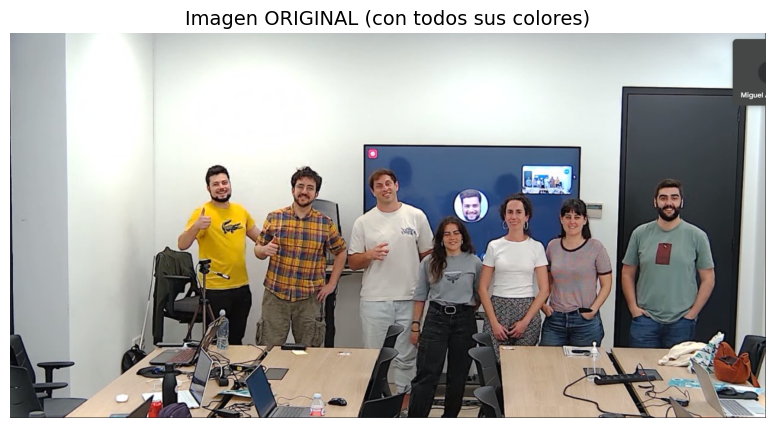

La imagen tiene millones de combinaciones de color posibles (256³ = 16,777,216)


In [5]:
# imshow() de matplotlib interpreta un array (alto, ancho, 3) como una imagen RGB
plt.figure(figsize=(12, 5))
plt.imshow(image)
plt.title('Imagen ORIGINAL (con todos sus colores)', fontsize=14)
plt.axis('off')  # Ocultamos los ejes — no tienen sentido en una imagen
plt.show()

print(f'La imagen tiene millones de combinaciones de color posibles (256³ = {256**3:,})')

---
## 3. Modifica la estructura de la imagen

K-Means necesita que cada **observación** sea una fila en una tabla.
Aquí, cada **píxel** es una observación, y sus 3 valores RGB son las **features**.

Por eso tenemos que transformar la imagen de:
- `(alto, ancho, 3)` → una matriz 3D (como un cubo)

a:
- `(alto × ancho, 3)` → una tabla 2D donde cada fila es un píxel

Ejemplo con imagen pequeña:
```
Antes (3, 4, 3):          Después (12, 3):
[ [[R,G,B], [R,G,B], ...  →   [R, G, B]
   [R,G,B], [R,G,B], ...       [R, G, B]
   ...]  ]                     ...
                                [R, G, B]   ← 12 filas en total
```

In [ ]:
# reshape(-1, 3) aplana las dos primeras dimensiones (alto y ancho) en una sola
# El -1 le dice a numpy: "calcula tú cuántas filas necesito" (= alto × ancho)
# El 3 mantiene los 3 canales de color como columnas
image_2d = image.reshape(-1, 3)

print(f'Shape ANTES del reshape: {image.shape}  → (alto, ancho, canales)')
print(f'Shape DESPUÉS del reshape: {image_2d.shape}  → (total_píxeles, canales)')
print(f'\nComprobación: {alto} × {ancho} = {alto * ancho:,} píxeles ✅')
print(f'\nPrimeros 5 píxeles (sus valores RGB):')
print(image_2d[:5])

In [ ]:
# Normalizamos los valores de [0, 255] a [0.0, 1.0]
# Esto NO es obligatorio para K-Means en imágenes, pero es buena práctica
# porque mantiene los valores en un rango estándar
image_2d_float = image_2d.astype(np.float64) / 255.0

print(f'Tipo antes de normalizar: {image_2d.dtype}  (enteros 0-255)')
print(f'Tipo tras normalizar:     {image_2d_float.dtype}  (decimales 0.0-1.0)')
print(f'\nPrimeros 5 píxeles normalizados:')
print(image_2d_float[:5].round(3))

---
## 4. K-Means

Ahora aplicamos K-Means sobre los píxeles. **K** es el número de colores que queremos en la imagen final.

Lo que hace el algoritmo:
1. Elige K puntos aleatorios como centroides iniciales (cada centroide es un color RGB)
2. Asigna cada píxel al centroide (color) más cercano
3. Recalcula cada centroide como el color promedio de todos los píxeles de su grupo
4. Repite hasta que los centroides no cambien

Con `K=8` reducimos la imagen a solo **8 colores**.

In [ ]:
# Definimos el número de colores que querdremos en la imagen final
# Puedes cambiarlo: con K=2 la imagen será muy simple, con K=20 más detallada
K = 8

# Creamos y entrenamos el modelo
# n_init=5: prueba 5 inicializaciones distintas y se queda con la mejor
# random_state=42: semilla para reproducibilidad (siempre da el mismo resultado)
kmeans = KMeans(n_clusters=K, n_init=5, random_state=42)
kmeans.fit(image_2d_float)

print(f'✅ K-Means entrenado con K = {K} colores')
print(f'\nLos {K} colores encontrados (centroides RGB normalizados 0-1):')
for i, color in enumerate(kmeans.cluster_centers_):
    r, g, b = (color * 255).astype(int)
    print(f'  Color {i}: R={r:3d}, G={g:3d}, B={b:3d}  →  {color.round(3)}')

---
## 5. Sustituye cada píxel por su centroide

Después de entrenar el modelo tenemos dos cosas clave:

- **`kmeans.labels_`**: un array de longitud `alto × ancho`. Para cada píxel, indica a qué cluster (0, 1, 2...) pertenece. Es como un carnet de identidad: *"el píxel número 1500 pertenece al color número 3"*.

- **`kmeans.cluster_centers_`**: un array de forma `(K, 3)`. Son los K colores promedio encontrados, los "representantes" de cada grupo.

La magia está en esta línea:
```python
cluster_centers_[labels_]
```
Esto usa los labels como índices para seleccionar colores del array de centroides. Si el píxel 0 tiene label 3, entonces se reemplaza por el color 3. Si el píxel 1 tiene label 7, se reemplaza por el color 7. ¡De golpe para todos los píxeles!

In [ ]:
print('Forma de labels_:', kmeans.labels_.shape)
print('Primeros 10 labels (a qué cluster pertenece cada píxel):')
print(kmeans.labels_[:10])

print(f'\nForma de cluster_centers_: {kmeans.cluster_centers_.shape}')
print('→ Hay', K, 'centroides, cada uno con 3 valores (R, G, B)')

In [ ]:
# Aquí está el truco: usamos los labels como índices del array de centroides
# Para cada píxel, en lugar de su color original, ponemos el color de su centroide
# Resultado: imagen con exactamente K colores distintos
image_comprimida = kmeans.cluster_centers_[kmeans.labels_]

print(f'Shape de la imagen comprimida: {image_comprimida.shape}')
print(f'→ Sigue siendo {alto * ancho:,} píxeles, pero ahora solo existen {K} colores únicos')
print(f'\nNúmero de colores únicos en imagen comprimida: {len(np.unique(image_comprimida, axis=0))}')

---
## 6. Recupera la estructura original de la imagen

Ahora mismo `image_comprimida` tiene forma `(alto × ancho, 3)` — una tabla larga.
Para poder **mostrarla como imagen** necesitamos volver a la forma `(alto, ancho, 3)` — el cubo original.

Es exactamente el proceso inverso al paso 3.

In [ ]:
# Devolvemos la imagen a su forma 3D original: (alto, ancho, 3)
# Usamos las dimensiones que guardamos al principio (alto, ancho, canales)
image_final = image_comprimida.reshape(alto, ancho, canales)

print(f'Shape ANTES de recuperar: {image_comprimida.shape}  → tabla plana (píxeles, colores)')
print(f'Shape DESPUÉS de recuperar: {image_final.shape}  → imagen 3D (alto, ancho, canales) ✅')

---
## 7. Muestra y guarda la imagen resultante

In [ ]:
# Mostramos original y comprimida lado a lado para comparar
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Imagen original
axes[0].imshow(image)
axes[0].set_title('Imagen ORIGINAL\n(millones de colores posibles)', fontsize=13)
axes[0].axis('off')

# Imagen comprimida — los valores están en [0,1] float, imshow los acepta directamente
axes[1].imshow(image_final)
axes[1].set_title(f'Imagen COMPRIMIDA con K-Means\n(solo {K} colores)', fontsize=13)
axes[1].axis('off')

plt.suptitle('Compresión de color mediante K-Means', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Guardamos la imagen en disco
# Primero convertimos de float [0,1] a uint8 [0,255] porque es el formato estándar de imagen
image_final_uint8 = (image_final * 255).astype(np.uint8)

# Guardamos usando PIL
Image.fromarray(image_final_uint8).save(f'imagen_comprimida_K{K}.png')
print(f'✅ Imagen guardada como "imagen_comprimida_K{K}.png"')

# También la podemos guardar con matplotlib directamente desde la figura
fig, ax = plt.subplots(figsize=(12, 5))
ax.imshow(image_final)
ax.set_title(f'Imagen con K={K} colores (K-Means)', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.savefig(f'kmeans_resultado_K{K}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Imagen guardada también como "kmeans_resultado_K{K}.png"')

---
## 8. Crea una función

Encapsulamos todo el proceso en una función reutilizable que acepta:
- `ruta_imagen`: la imagen que quieras comprimir
- `k`: cuántos colores quieres en el resultado
- `guardar`: si quieres guardarla en disco (True/False)
- `mostrar`: si quieres verla en pantalla (True/False)

In [ ]:
def comprimir_imagen_kmeans(ruta_imagen, k=8, guardar=False, mostrar=True):
    """
    Comprime una imagen reduciendo su paleta de colores a K colores mediante K-Means.
    
    Parámetros:
    -----------
    ruta_imagen : str
        Ruta al archivo de imagen (jpg, png, etc.)
    k : int
        Número de colores en la imagen resultante (default: 8)
    guardar : bool
        Si True, guarda la imagen resultante en disco (default: False)
    mostrar : bool
        Si True, muestra la comparación original vs comprimida (default: True)
    
    Retorna:
    --------
    image_final : np.ndarray
        La imagen comprimida como array numpy con shape (alto, ancho, 3), valores en [0, 1]
    """

    # ── PASO 1: Leer la imagen ──────────────────────────────────────────────────
    # Cargamos con PIL para que funcione con jpg, png y otros formatos
    image = np.array(Image.open(ruta_imagen))

    # Si la imagen tiene canal alfa (RGBA = 4 canales), nos quedamos solo con RGB
    if image.shape[2] == 4:
        image = image[:, :, :3]

    # Guardamos las dimensiones originales para poder reconstruir la imagen al final
    alto, ancho, canales = image.shape
    print(f'📷 Imagen cargada: {ancho}×{alto} px | {alto * ancho:,} píxeles en total')

    # ── PASO 2: Aplanar la imagen ───────────────────────────────────────────────
    # De (alto, ancho, 3) a (alto*ancho, 3)
    # Cada fila es un píxel con sus 3 valores RGB
    image_2d = image.reshape(-1, 3).astype(np.float64) / 255.0

    # ── PASO 3: Entrenar K-Means ────────────────────────────────────────────────
    # Cada píxel es un punto en el espacio 3D (R, G, B)
    # K-Means los agrupa en K clusters y encuentra el color promedio de cada uno
    print(f'⚙️  Entrenando K-Means con K={k} colores...')
    kmeans = KMeans(n_clusters=k, n_init=5, random_state=42)
    kmeans.fit(image_2d)
    print(f'✅ K-Means completado!')

    # ── PASO 4: Sustituir cada píxel por el color de su centroide ──────────────
    # labels_: qué cluster tiene asignado cada píxel (array de tamaño alto*ancho)
    # cluster_centers_: los K colores promedio encontrados (array de forma K×3)
    # Usamos labels_ como índices: cluster_centers_[labels_] → devuelve el color
    # del centroide correspondiente para cada píxel en una sola operación
    image_comprimida = kmeans.cluster_centers_[kmeans.labels_]

    # ── PASO 5: Reconstruir la forma 3D de la imagen ────────────────────────────
    # Volvemos de (alto*ancho, 3) a (alto, ancho, 3)
    image_final = image_comprimida.reshape(alto, ancho, canales)

    # ── PASO 6: Mostrar si se pide ──────────────────────────────────────────────
    if mostrar:
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))

        axes[0].imshow(image)
        axes[0].set_title('Imagen ORIGINAL\n(todos los colores)', fontsize=13)
        axes[0].axis('off')

        axes[1].imshow(image_final)
        axes[1].set_title(f'Imagen COMPRIMIDA\n(solo {k} colores)', fontsize=13)
        axes[1].axis('off')

        plt.suptitle(f'K-Means: compresión de color con K={k}', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

    # ── PASO 7: Guardar si se pide ──────────────────────────────────────────────
    if guardar:
        # Convertimos de float [0,1] a uint8 [0,255] para guardar correctamente
        nombre_salida = f'comprimida_K{k}.png'
        Image.fromarray((image_final * 255).astype(np.uint8)).save(nombre_salida)
        print(f'💾 Imagen guardada como "{nombre_salida}"')

    return image_final


print('✅ Función definida correctamente')

In [ ]:
# ── Probamos la función con distintos valores de K ──────────────────────────────
# Cuantos menos colores (K pequeño), más abstracta y simplificada queda la imagen
# Cuantos más colores (K grande), más parecida a la original

for k in [2, 4, 8, 16]:
    print(f'\n{"="*50}')
    print(f'Comprimiendo con K = {k} colores...')
    comprimir_imagen_kmeans('ejer_kmeans.png', k=k, guardar=False, mostrar=True)

In [ ]:
# ── Llamada con guardado en disco ───────────────────────────────────────────────
resultado = comprimir_imagen_kmeans('ejer_kmeans.png', k=8, guardar=True, mostrar=True)

print(f'\nLa función devuelve un array numpy de shape: {resultado.shape}')
print('Puedes seguir trabajando con él como quieras.')